# Project: end-to-end Fashion-MNIST classifier

**Learning objective:** Take real image data from acquisition and EDA through baseline/CNN comparison, untouched-test evaluation, error analysis, calibration, serialization, inference and drift simulation.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import json, time
PROJECT=Path("CNN/projects/fashion_mnist_classifier")
(PROJECT/"artifacts").mkdir(parents=True,exist_ok=True)
(PROJECT/"reports").mkdir(parents=True,exist_ok=True)
names=np.array(["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"])


2026-09-21 07:16:39.753152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974999.769370    4389 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974999.773825    4389 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:16:41.482327: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Problem and split contract
        **Goal:** classify a 28×28 grayscale apparel image into one of ten classes. We use TensorFlow's canonical Fashion-MNIST loader. Validation is carved only from the original training partition; the canonical test partition remains untouched until final evaluation.


In [2]:
(x_all,y_all),(x_test_all,y_test_all)=tf.keras.datasets.fashion_mnist.load_data()
print("canonical training:",x_all.shape,y_all.shape,"canonical test:",x_test_all.shape,y_test_all.shape); print("pixel range:",(x_all.min(),x_all.max()))
display(pd.Series(y_all).value_counts().sort_index().rename(index=dict(enumerate(names))).to_frame("count"))


canonical training: (60000, 28, 28) (60000,) canonical test: (10000, 28, 28) (10000,)
pixel range: (np.uint8(0), np.uint8(255))


,count
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


## 2. EDA
        Visual inspection checks whether labels and image semantics align and exposes the inherent ambiguity between visually similar classes such as shirts, T-shirts, coats and pullovers.


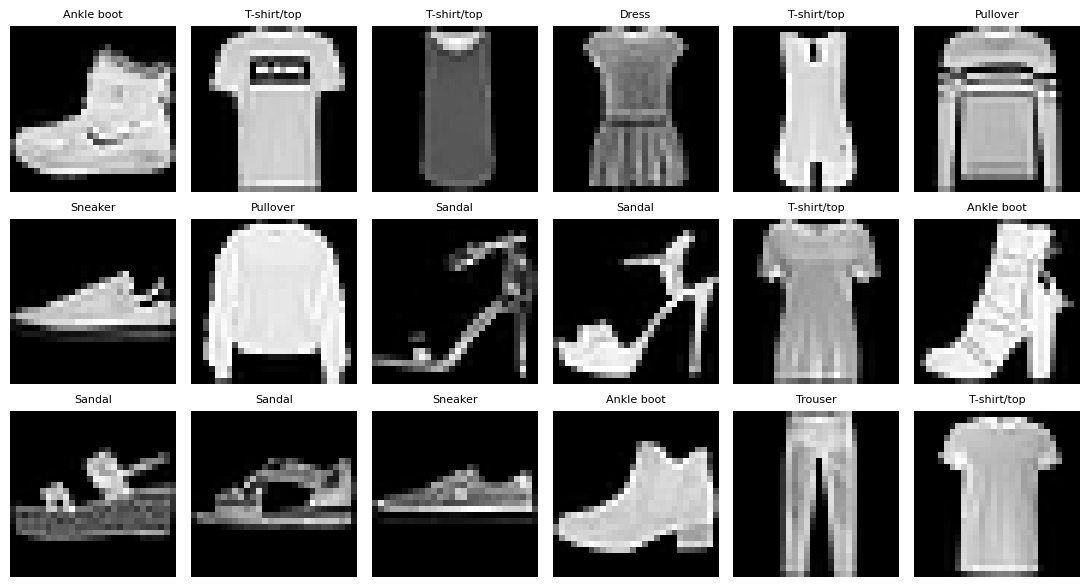

In [3]:
fig,axes=plt.subplots(3,6,figsize=(11,6))
for ax,img,label in zip(axes.flat,x_all[:18],y_all[:18]): ax.imshow(img,cmap="gray"); ax.set_title(names[label],fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()


## 3. Deterministic train/validation/test subsets and normalization
        A compact subset keeps the notebook practical on CPU while preserving all 10 classes. Pixel scaling to `[0,1]` is deterministic and does not learn statistics from test data.


In [4]:
rng=np.random.default_rng(SEED); idx=rng.permutation(len(x_all)); train_idx=idx[:12000]; val_idx=idx[12000:14000]
Xtr=x_all[train_idx,...,None].astype("float32")/255; ytr=y_all[train_idx]
Xva=x_all[val_idx,...,None].astype("float32")/255; yva=y_all[val_idx]
Xte=x_test_all[:3000,...,None].astype("float32")/255; yte=y_test_all[:3000]
print("train/val/test:",Xtr.shape,Xva.shape,Xte.shape)


train/val/test: (12000, 28, 28, 1) (2000, 28, 28, 1) (3000, 28, 28, 1)


## 4. Dense baseline
        Flattening discards explicit spatial structure. That makes an MLP a useful baseline: if convolution helps, it should beat or match this simpler hypothesis under the same data contract.


In [5]:
def build_mlp():
    m=tf.keras.Sequential([tf.keras.layers.Input((28,28,1)),tf.keras.layers.Flatten(),tf.keras.layers.Dense(128,activation="relu"),tf.keras.layers.Dense(10,activation="softmax")],name="mlp_baseline")
    m.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"]); return m
tf.keras.utils.set_random_seed(SEED); mlp=build_mlp(); h_mlp=mlp.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=2,batch_size=64,verbose=0); print("MLP parameters:",mlp.count_params()); display(pd.DataFrame(h_mlp.history).round(4))


MLP parameters: 101770


,accuracy,loss,val_accuracy,val_loss
0,0.7543,0.7269,0.8235,0.5373
1,0.8263,0.4904,0.8430,0.4764


## 5. CNN model
        The CNN preserves local neighborhoods through two convolution/pooling stages, then uses a compact dense head. Dropout regularizes the representation.


In [6]:
def build_cnn():
    m=tf.keras.Sequential([tf.keras.layers.Input((28,28,1)),tf.keras.layers.Conv2D(32,3,padding="same",activation="relu",name="conv1"),tf.keras.layers.MaxPooling2D(),tf.keras.layers.Conv2D(64,3,padding="same",activation="relu",name="conv2"),tf.keras.layers.MaxPooling2D(),tf.keras.layers.Flatten(),tf.keras.layers.Dense(64,activation="relu"),tf.keras.layers.Dropout(.2),tf.keras.layers.Dense(10,activation="softmax")],name="cnn")
    m.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"]); return m
tf.keras.utils.set_random_seed(SEED); cnn=build_cnn(); cnn.summary(); h_cnn=cnn.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=2,batch_size=64,verbose=0); display(pd.DataFrame(h_cnn.history).round(4))


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

,accuracy,loss,val_accuracy,val_loss
0,0.7064,0.8067,0.8180,0.5117
1,0.8301,0.4798,0.8495,0.4235


## 6. Validation-based model selection
        Test data still has not been used. We choose using validation accuracy only.


In [7]:
comparison=pd.DataFrame([{"model":"MLP","best_val_accuracy":max(h_mlp.history["val_accuracy"]),"parameters":mlp.count_params()},{"model":"CNN","best_val_accuracy":max(h_cnn.history["val_accuracy"]),"parameters":cnn.count_params()}]).sort_values("best_val_accuracy",ascending=False)
display(comparison.round(4)); selected=comparison.iloc[0]["model"]; best=cnn if selected=="CNN" else mlp; print("selected:",selected)


,model,best_val_accuracy,parameters
1,CNN,0.8495,220234
0,MLP,0.8430,101770


selected: CNN


## 7. Final untouched test evaluation


In [8]:
prob=best.predict(Xte,batch_size=128,verbose=0); pred=prob.argmax(1); test_acc=accuracy_score(yte,pred)
report=classification_report(yte,pred,target_names=names,output_dict=True,zero_division=0)
print("test accuracy:",round(float(test_acc),4)); display(pd.DataFrame(report).T.loc[names,["precision","recall","f1-score","support"]].round(3))


test accuracy: 0.8547


,precision,recall,f1-score,support
T-shirt/top,0.852,0.742,0.793,302.0
Trouser,0.980,0.977,0.979,308.0
Pullover,0.805,0.719,0.760,310.0
Dress,0.838,0.866,0.851,298.0
Coat,0.676,0.883,0.766,324.0
Sandal,0.942,0.968,0.955,285.0
Shirt,0.653,0.567,0.607,298.0
Sneaker,0.923,0.939,0.931,293.0
Bag,0.966,0.963,0.965,297.0
Ankle boot,0.964,0.933,0.948,285.0


## 8. Confusion and misclassification analysis


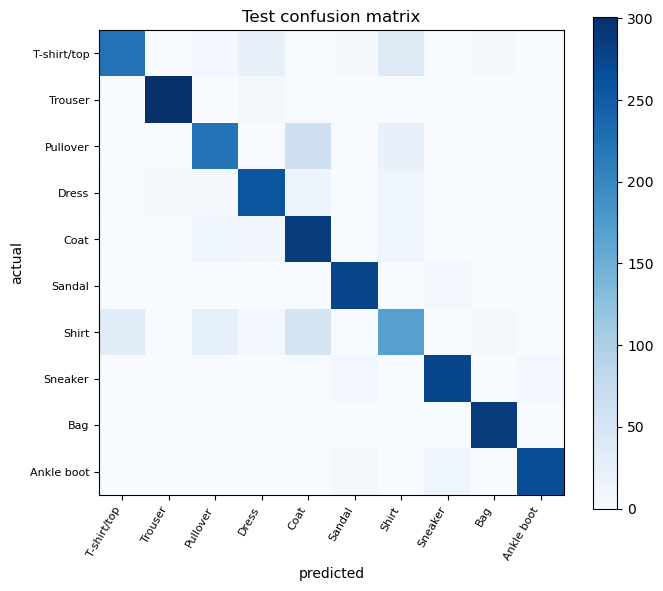

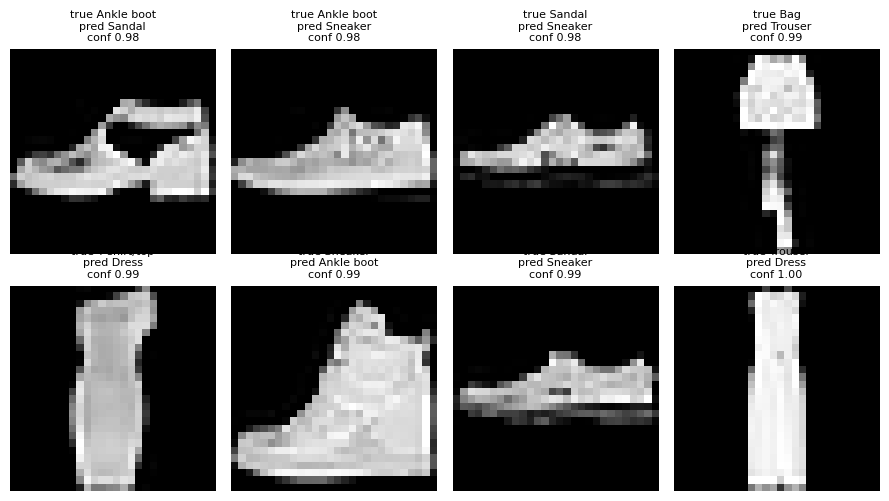

In [9]:
cm=confusion_matrix(yte,pred); plt.figure(figsize=(7,6)); plt.imshow(cm,cmap="Blues"); plt.colorbar(); plt.xticks(range(10),names,rotation=60,ha="right",fontsize=8); plt.yticks(range(10),names,fontsize=8); plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Test confusion matrix"); plt.tight_layout(); plt.show()
wrong=np.where(pred!=yte)[0]; hardest=wrong[np.argsort(prob[wrong,pred[wrong]])[-8:]] if len(wrong)>=8 else wrong
fig,axes=plt.subplots(2,4,figsize=(9,5))
for ax,i in zip(axes.flat,hardest): ax.imshow(Xte[i,:,:,0],cmap="gray"); ax.set_title(f"true {names[yte[i]]}\npred {names[pred[i]]}\nconf {prob[i,pred[i]]:.2f}",fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()


## 9. Calibration diagnostic
        Accuracy and confidence are different properties. Expected calibration error (ECE) compares confidence with empirical correctness across bins.


In [10]:
conf=prob.max(1); correct=(pred==yte).astype(float); bins=np.linspace(0,1,11); ece=0.; rows=[]
for lo,hi in zip(bins[:-1],bins[1:]):
    m=(conf>=lo)&(conf<hi)
    if m.any():
        acc=correct[m].mean(); c=conf[m].mean(); ece += m.mean()*abs(acc-c); rows.append({"bin":f"{lo:.1f}-{hi:.1f}","n":int(m.sum()),"accuracy":acc,"confidence":c})
display(pd.DataFrame(rows).round(3)); print("ECE:",round(float(ece),4))


,bin,n,accuracy,confidence
0,0.2-0.3,10,0.700,0.274
1,0.3-0.4,82,0.329,0.358
2,0.4-0.5,159,0.478,0.457
3,0.5-0.6,253,0.609,0.552
4,0.6-0.7,228,0.671,0.650
5,0.7-0.8,288,0.806,0.751
6,0.8-0.9,332,0.883,0.851
7,0.9-1.0,1648,0.984,0.980


ECE: 0.0205


## 10. Persist model, metrics, history and predictions


In [11]:
model_path=PROJECT/"artifacts"/"best_model.keras"; best.save(model_path)
metrics={"selected_model":selected,"test_accuracy":float(test_acc),"ece":float(ece),"validation_accuracy":float(comparison.iloc[0]["best_val_accuracy"])}
(PROJECT/"reports"/"metrics.json").write_text(json.dumps(metrics,indent=2))
hist=h_cnn.history if selected=="CNN" else h_mlp.history; pd.DataFrame(hist).to_csv(PROJECT/"reports"/"training_history.csv",index=False)
pd.DataFrame({"actual":yte[:1000],"predicted":pred[:1000],"confidence":conf[:1000]}).to_csv(PROJECT/"reports"/"predictions.csv",index=False)
print("saved:",model_path); print(metrics)


saved: CNN/projects/fashion_mnist_classifier/artifacts/best_model.keras
{'selected_model': 'CNN', 'test_accuracy': 0.8546666666666667, 'ece': 0.020532834649085972, 'validation_accuracy': 0.8495000004768372}


## 11. Reloaded inference


In [12]:
restored=tf.keras.models.load_model(model_path); one=restored.predict(Xte[:1],verbose=0)[0]; print("actual:",names[yte[0]],"predicted:",names[one.argmax()],"confidence:",round(float(one.max()),4))


actual: Ankle boot predicted: Ankle boot confidence: 0.9055


## 12. Monitoring simulation
        We darken images to mimic an input-distribution change, then compare confidence and accuracy. This is not a complete drift detector; it demonstrates the operational question a monitoring layer must answer.


In [13]:
shifted=Xte*.65; p_shift=restored.predict(shifted,batch_size=128,verbose=0); pred_shift=p_shift.argmax(1)
monitor=pd.DataFrame({"population":["reference test","darkened simulation"],"pixel_mean":[Xte.mean(),shifted.mean()],"accuracy":[test_acc,accuracy_score(yte,pred_shift)],"mean_confidence":[prob.max(1).mean(),p_shift.max(1).mean()]})
display(monitor.round(4))


,population,pixel_mean,accuracy,mean_confidence
0,reference test,0.2873,0.8547,0.8357
1,darkened simulation,0.1867,0.8533,0.7545


## Project conclusion
        This project demonstrates the full experimental path from raw dataset loading through model choice and final evaluation to deployable artifacts and post-deployment diagnostics. Production extensions include data/version lineage, service-level latency/load tests, class-specific monitoring and governed retraining.
